In [ ]:
import os
import json
from typing import TypedDict, Annotated
from dotenv import load_dotenv

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue, Range

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

load_dotenv()

In [2]:
QDRANT_URL      = os.getenv("QDRANT_URL")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY")
GOOGLE_API_KEY  = os.getenv("GOOGLE_API_KEY")
COLLECTION_NAME = "Job_Description"
TOP_K           = 10
EMBEDDING_MODEL = "keepitreal/vietnamese-sbert"

print("Loading embedding model...")
embed_model = SentenceTransformer(EMBEDDING_MODEL)
print("Embedding model loaded.")

qdrant_client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=60)
print("Qdrant connected.")

def initialize_llm():
    return ChatGoogleGenerativeAI(
        model="gemini-3.1-flash-lite-preview",
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=5,
        google_api_key=GOOGLE_API_KEY,
    )

llm = initialize_llm()
print("LLM ready.")

Loading embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6081.36it/s]


Embedding model loaded.
Qdrant connected.
LLM ready.


### State

In [3]:
class AgentState(TypedDict):
    cv_text:        str
    preferences:    str
    filters:        dict
    retrieved_jobs: list
    summary:        str
    messages:       Annotated[list, lambda x, y: x + y]

In [ ]:
def _format_job(hit) -> dict:
    p = hit.payload
    return {
        "score":               round(hit.score, 4),
        "job_title":           p.get("job_title"),
        "category":            p.get("category"),
        "location":            p.get("location"),
        "country":             p.get("country"),
        "qualifications":      p.get("qualifications"),
        "languages_required":  p.get("languages_required"),
        "experience_required": p.get("experience_required"),
        "contract_type":       p.get("contract_type"),
        "working_hours":       p.get("working_hours"),
        "salary_min":          p.get("salary_min"),
        "salary_max":          p.get("salary_max"),
        "salary_avg":          p.get("salary_avg"),
        "benefits":            p.get("benefits"),
        "technical_skills":    p.get("technical_skills"),
        "soft_skills":         p.get("soft_skills"),
        "description":         p.get("description"),
        "requirements_text":   p.get("requirements_text"),
    }


@tool
def semantic_search(query: str) -> list[dict]:
    """Search for relevant jobs using semantic similarity only.
    Use this as fallback when no filters can be extracted at all."""
    vector = embed_model.encode(query).tolist()
    hits = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=vector,
        limit=TOP_K,
        with_payload=True,
    ).points
    return [_format_job(h) for h in hits]


@tool
def filtered_search(
    query: str,
    location: str = None,
    country: str = None,
    category: str = None,
    contract_type: str = None,
    working_hours: str = None,
    languages_required: str = None,
    experience_required: str = None,
    qualifications: str = None,
    salary_min: float = None,
    salary_max: float = None,
    salary_avg: float = None,
) -> str:
    """Search jobs using semantic similarity combined with metadata filters.
    Use this when any filter can be extracted from user preferences or CV.
    All parameters are optional — only pass what you can confidently extract.

    Metadata schema:
    - location
    - country
    - category
    - contract_type
    - working_hours
    - languages_required
    - experience_required
    - qualifications
    - salary_min
    - salary_max
    - salary_avg
    """
    vector = embed_model.encode(query).tolist()

    conditions = []
    if location:
        conditions.append(FieldCondition(key="location", match=MatchValue(value=location)))
    if country:
        conditions.append(FieldCondition(key="country", match=MatchValue(value=country)))
    if category:
        conditions.append(FieldCondition(key="category", match=MatchValue(value=category)))
    if contract_type:
        conditions.append(FieldCondition(key="contract_type", match=MatchValue(value=contract_type)))
    if working_hours:
        conditions.append(FieldCondition(key="working_hours", match=MatchValue(value=working_hours)))
    if languages_required:
        conditions.append(FieldCondition(key="languages_required", match=MatchValue(value=languages_required)))
    if experience_required:
        conditions.append(FieldCondition(key="experience_required", match=MatchValue(value=experience_required)))
    if qualifications:
        conditions.append(FieldCondition(key="qualifications", match=MatchValue(value=qualifications)))
    if salary_min or salary_max:
        conditions.append(FieldCondition(
            key="salary_min",
            range=Range(
                gte=salary_min if salary_min else None,
                lte=salary_max if salary_max else None,
            )
        ))
    if salary_avg:
        conditions.append(FieldCondition(
            key="salary_avg",
            range=Range(gte=salary_avg)
        ))

    # job only needs to match at least one condition
    qdrant_filter = Filter(should=conditions) if conditions else None

    hits = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=vector,
        query_filter=qdrant_filter,
        limit=TOP_K,
        with_payload=True,
    ).points

    # if filtered search returns nothing, drop filters and search purely by vector
    if not hits:
        print("[filtered_search] No results with filters — falling back to semantic search.")
        hits = qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=vector,
            limit=TOP_K,
            with_payload=True,
        ).points

    return json.dumps([_format_job(h) for h in hits], ensure_ascii=False)


tools     = [semantic_search, filtered_search]
tool_node = ToolNode(tools)
print("Tools registered.")

Tools registered.


### Agent Node

In [5]:
AGENT_SYSTEM_PROMPT = """Bạn là một AI chuyên tư vấn nghề nghiệp.
Bạn sẽ nhận được CV và sở thích/yêu cầu của người dùng.

Bạn có 2 công cụ:
- filtered_search: tìm kiếm kết hợp vector + bộ lọc metadata
- semantic_search: tìm kiếm thuần vector, chỉ dùng khi không trích xuất được bất kỳ bộ lọc nào

Quy trình:
1. Đọc phần "Sở thích & Yêu cầu" để trích xuất các bộ lọc metadata
2. Nếu trích xuất được ít nhất 1 bộ lọc → gọi filtered_search
3. Nếu không trích xuất được gì → gọi semantic_search

Chỉ gọi đúng 1 công cụ.
Không bịa đặt giá trị bộ lọc — chỉ dùng những gì người dùng đề cập rõ ràng."""


def agent_node(state: AgentState) -> AgentState:
    cv_text     = state["cv_text"]
    preferences = state["preferences"]

    user_message = f"""CV:
{cv_text}

Sở thích & Yêu cầu:
{preferences}"""

    messages = [
        SystemMessage(content=AGENT_SYSTEM_PROMPT),
        HumanMessage(content=user_message),
    ]

    llm_with_tools = llm.bind_tools(tools)
    response       = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "summary"


def collect_results_node(state: AgentState) -> AgentState:
    retrieved_jobs = []
    for msg in reversed(state["messages"]):
        if hasattr(msg, "content"):
            content = msg.content
            if isinstance(content, list):
                for block in content:
                    if isinstance(block, dict) and block.get("type") == "text":
                        content = block.get("text", "")
                        break
            if isinstance(content, str) and content.strip():
                try:
                    data = json.loads(content)
                    if isinstance(data, list):
                        retrieved_jobs = data
                        break
                except (json.JSONDecodeError, TypeError):
                    continue
    return {"retrieved_jobs": retrieved_jobs}

### Summary Node

In [6]:
SUMMARY_SYSTEM_PROMPT = """Bạn là chuyên gia tư vấn nghề nghiệp.
Dựa trên CV và sở thích của người dùng cùng danh sách việc làm tìm được,
hãy viết một đoạn tóm tắt ngắn gọn bằng tiếng Việt:
- Những vị trí nào phù hợp nhất và tại sao
- Yêu cầu kỹ năng chính của các vị trí đó
- Lời khuyên ngắn cho người dùng

Giữ tóm tắt trong 150-200 từ."""


def summary_node(state: AgentState) -> AgentState:
    cv_text     = state["cv_text"]
    preferences = state["preferences"]
    jobs        = state.get("retrieved_jobs", [])

    if not jobs:
        return {"summary": "Không tìm thấy việc làm phù hợp."}

    jobs_text = json.dumps(jobs[:5], ensure_ascii=False, indent=2)
    messages  = [
        SystemMessage(content=SUMMARY_SYSTEM_PROMPT),
        HumanMessage(content=f"CV:\n{cv_text}\n\nSở thích:\n{preferences}\n\nViệc làm tìm được:\n{jobs_text}"),
    ]

    response = llm.invoke(messages)
    return {"summary": response.content}

### Graph 

Graph compiled.


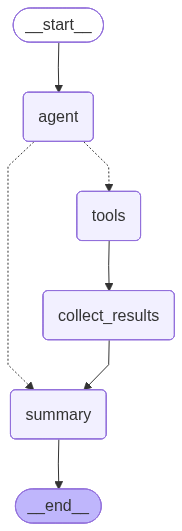

In [7]:
graph = StateGraph(AgentState)

graph.add_node("agent",            agent_node)
graph.add_node("tools",            tool_node)
graph.add_node("collect_results",  collect_results_node)
graph.add_node("summary",          summary_node)

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "summary": "summary"},
)

graph.add_edge("tools",            "collect_results")
graph.add_edge("collect_results",  "summary")
graph.add_edge("summary",          END)

app = graph.compile()
print("Graph compiled.")

app

### Run + Display

In [11]:
cv_text = """
Tôi có 2 năm kinh nghiệm lập trình Python. Đã thực hiện các dự án phân tích
dữ liệu và machine learning. Thành thạo SQL, Pandas, Scikit-learn, Git.
Tốt nghiệp Đại học Bách Khoa Đà Nẵng chuyên ngành Khoa học Máy tính.
"""

preferences = """
Muốn làm việc tại Đà Nẵng. Ưu tiên công việc full-time.
Mức lương mong muốn tối thiểu 15 triệu. Có thể làm việc bằng tiếng Anh.
"""

initial_state: AgentState = {
    "cv_text":        cv_text,
    "preferences":    preferences,
    "filters":        {},
    "retrieved_jobs": [],
    "summary":        "",
    "messages":       [],
}

result = app.invoke(initial_state)

print("=" * 60)
print("DEBUG — ALL MESSAGES IN STATE\n")
for i, msg in enumerate(result["messages"]):
    print(f"[{i}] Type: {type(msg).__name__}")
    print(f"     Content: {msg.content}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"     Tool Calls: {msg.tool_calls}")
    if hasattr(msg, "name"):
        print(f"     Tool Name: {msg.name}")
    print()

print("=" * 60)
print("RETRIEVED JOBS RAW\n")
for i, job in enumerate(result["retrieved_jobs"], 1):
    print(f"[{i}] {job['job_title']} | {job['category']} | {job['location']}")
    print(f"    Kinh nghiệm : {job['experience_required']}")
    print(f"    Hợp đồng    : {job['contract_type']}")
    print(f"    Lương       : {job['salary_min']} - {job['salary_max']}")
    print(f"    Kỹ năng     : {job['technical_skills']}")
    print(f"    Độ phù hợp  : {job['score']}")
    print()

print("=" * 60)
print("FILTERS EXTRACTED\n")
print(result["filters"])

print("=" * 60)
print("TÓM TẮT AI:\n")
print(result["summary"])


DEBUG — ALL MESSAGES IN STATE

[0] Type: AIMessage
     Content: []
     Tool Calls: [{'name': 'filtered_search', 'args': {'query': 'Python Developer Data Science Machine Learning', 'location': 'Đà Nẵng', 'languages_required': 'Tiếng Anh', 'salary_min': 15000000, 'contract_type': 'Full-time', 'experience_required': '2 năm'}, 'id': '8308e5c3-25f2-4060-aec5-e0a71795c59e', 'type': 'tool_call'}]
     Tool Name: None

[1] Type: ToolMessage
     Content: [{"score": 0.5303, "job_title": "Data Scientist", "category": "thiết_kế_nghệ_thuật_giải_trí_truyền_hình_báo_chí", "location": "new york", "country": "Mỹ", "qualifications": "[\"Master's degree in Computer Science or related field\", 'PhD preferred']", "languages_required": "tiếng anh", "experience_required": "2 năm", "contract_type": "Toàn thời gian", "working_hours": "9-5", "salary_min": 0.0, "salary_max": 0.0, "salary_avg": null, "benefits": "['Health insurance', 'Paid time off', '401k']", "technical_skills": "['Python', 'SQL', 'Machine Le

In [9]:
# Run once
from qdrant_client.models import PayloadSchemaType

keyword_fields = [
    "location", "country", "category", "contract_type",
    "working_hours", "languages_required", "experience_required", "qualifications"
]

float_fields = ["salary_min", "salary_max", "salary_avg"]

for field in keyword_fields:
    qdrant_client.create_payload_index(
        collection_name=COLLECTION_NAME,
        field_name=field,
        field_schema=PayloadSchemaType.KEYWORD,
    )
    print(f"Index created: {field}")

for field in float_fields:
    qdrant_client.create_payload_index(
        collection_name=COLLECTION_NAME,
        field_name=field,
        field_schema=PayloadSchemaType.FLOAT,
    )
    print(f"Index created: {field}")

print("All indexes created.")

Index created: location
Index created: country
Index created: category
Index created: contract_type
Index created: working_hours
Index created: languages_required
Index created: experience_required
Index created: qualifications
Index created: salary_min
Index created: salary_max
Index created: salary_avg
All indexes created.
